# Near-Duplicate Review and Dataset Leakage Analysis

This notebook reviews near-duplicate images detected across the
train, validation, and test splits of the Domestic Animal Classification
dataset.

## Objective

The goal is to identify potential cross-split image leakage while
preserving as much valid training data as possible.

The workflow is:

1. Load pHash-based near-duplicate results.
2. Focus on the highest-confidence pHash candidates.
3. Verify candidates using ORB feature matching.
4. Validate the ORB matching threshold using representative examples.
5. Group connected duplicate candidates.
6. Preserve the highest-priority dataset split.
7. Generate a cleanup recommendation report.

No files are deleted automatically in this notebook.

In [43]:
from pathlib import Path
from PIL import Image

import cv2
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
# Paths
RESULTS_DIR = Path("../results")

CROSS_SPLIT_FILE = RESULTS_DIR / "cross_split_near_duplicates.csv"
CLEANUP_REPORT_FILE = RESULTS_DIR / "final_duplicate_cleanup_report.csv"

In [45]:
# Duplicate-detection configuration
PHASH_DISTANCE = 0
ORB_INLIER_THRESHOLD = 11

# Dataset split priority
# Higher priority means the image is preferred for retention.
SPLIT_PRIORITY = {
    "train": 1,
    "validation": 2,
    "test": 3,
}

## 1. Load Near-Duplicate Results

The previous notebook (`03_check_near_duplicates.ipynb`) detected
near-duplicate image pairs using perceptual hashing (pHash).

This notebook uses the saved cross-split results rather than
re-running the pHash search.

In [46]:
# Make sure the previous notebook has produced the required results file.
if not CROSS_SPLIT_FILE.exists():
    raise FileNotFoundError(
        f"Required file not found: {CROSS_SPLIT_FILE}"
    )

review_df = pd.read_csv(CROSS_SPLIT_FILE)

print(f"Cross-split near-duplicate pairs: {len(review_df)}")

Cross-split near-duplicate pairs: 382


In [47]:
# Summarize the pHash distance distribution.
distance_counts = (
    review_df["distance"]
    .value_counts()
    .sort_index()
)

print("pHash distance distribution:")
display(distance_counts)

pHash distance distribution:


distance
0    333
2     44
4      5
Name: count, dtype: int64

## 2. Select High-Confidence pHash Candidates

A pHash distance of 0 indicates that two images have identical
perceptual hashes.

These pairs are selected for additional verification using ORB.

In [48]:
# Select cross-split pairs with identical perceptual hashes.
high_confidence = review_df[
    review_df["distance"] == PHASH_DISTANCE
].copy()

print(
    f"pHash-distance-{PHASH_DISTANCE} candidates: "
    f"{len(high_confidence)}"
)

pHash-distance-0 candidates: 333


In [49]:
# Show the candidate distribution across dataset classes.
print("Candidates by class:")
display(high_confidence["class1"].value_counts())

Candidates by class:


class1
Chicken    91
Donkey     87
Horse      64
Goat       29
Sheep      28
Camel      26
Pig         8
Name: count, dtype: int64

## 3. Verify Candidates Using ORB

Perceptual hashing is useful for finding visually similar images,
but it is not sufficient by itself to determine whether two files
represent the same underlying image.

ORB feature matching is therefore used as a second verification step.

Two values are recorded:

- Good matches: feature correspondences that pass Lowe's ratio test.
- Inliers: matches that remain geometrically consistent after RANSAC.

The current experimental threshold is 11 ORB inliers.

In [51]:
def orb_match_score(image_path_1, image_path_2):
    """
    Compare two images using ORB feature matching.

    Returns:
        good_matches: Number of reliable feature matches.
        inliers: Number of geometrically consistent matches.
    """

    image_1 = cv2.imread(str(image_path_1), cv2.IMREAD_GRAYSCALE)
    image_2 = cv2.imread(str(image_path_2), cv2.IMREAD_GRAYSCALE)

    if image_1 is None or image_2 is None:
        return 0, 0

    orb = cv2.ORB_create(nfeatures=1000)

    keypoints_1, descriptors_1 = orb.detectAndCompute(image_1, None)
    keypoints_2, descriptors_2 = orb.detectAndCompute(image_2, None)

    if descriptors_1 is None or descriptors_2 is None:
        return 0, 0

    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = matcher.knnMatch(
        descriptors_1,
        descriptors_2,
        k=2
    )

    # Keep matches that pass Lowe's ratio test.
    good_matches = []

    for match_pair in matches:
        if len(match_pair) == 2:
            match_1, match_2 = match_pair

            if match_1.distance < 0.75 * match_2.distance:
                good_matches.append(match_1)

    if len(good_matches) < 4:
        return len(good_matches), 0

    points_1 = np.float32(
        [keypoints_1[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    points_2 = np.float32(
        [keypoints_2[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    _, mask = cv2.findHomography(
        points_1,
        points_2,
        cv2.RANSAC,
        5.0
    )

    inliers = int(mask.sum()) if mask is not None else 0

    return len(good_matches), inliers

In [52]:
# Verify every pHash-distance-0 candidate using ORB.
orb_results = []

for _, row in high_confidence.iterrows():

    good_matches, inliers = orb_match_score(
        row["image1"],
        row["image2"]
    )

    orb_results.append({
        "image1": row["image1"],
        "split1": row["split1"],
        "class1": row["class1"],
        "image2": row["image2"],
        "split2": row["split2"],
        "class2": row["class2"],
        "phash_distance": row["distance"],
        "good_matches": good_matches,
        "inliers": inliers,
    })

orb_df = pd.DataFrame(orb_results)

print(f"ORB verification completed: {len(orb_df)} pairs")

ORB verification completed: 333 pairs


## 4. Validate the ORB Threshold

The initial pHash-distance-0 set contained 333 cross-split pairs.

Several representative pairs near the lower end of the ORB inlier
range were visually inspected.

The inspected examples had 11, 16, 20, 26, and 47 inliers, and all
five inspected pairs represented the same underlying image.

Based on this validation, 11 inliers is used as the current working
threshold for automated cleanup candidate selection.

This threshold is treated as an empirical project rule rather than
a universal ORB threshold.

In [10]:
high_confidence = review_df[
    review_df["distance"] == 0
].copy()

print(f"High-confidence cross-split pairs: {len(high_confidence)}")

print("\nDistribution by class:")
print(high_confidence["class1"].value_counts())

print("\nDistribution by split combination:")
print(
    high_confidence[
        ["split1", "split2"]
    ].value_counts()
)

High-confidence cross-split pairs: 333

Distribution by class:
class1
Chicken    91
Donkey     87
Horse      64
Goat       29
Sheep      28
Camel      26
Pig         8
Name: count, dtype: int64

Distribution by split combination:
split1      split2    
train       test          170
            validation    104
validation  test           59
Name: count, dtype: int64


In [11]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   --- ------------------------------------ 3.4/44.0 MB 13.2 MB/s eta 0:00:04
   -------- ------------------------------- 8.9/44.0 MB 19.1 MB/s eta 0:00:02
   ------------- -------------------------- 15.2/44.0 MB 22.4 MB/s eta 0:00:02
   ----------------- ---------------------- 19.1/44.0 MB 22.7 MB/s eta 0:00:02
   --------------------- ------------------ 23.6/44.0 MB 21.3 MB/s eta 0:00:01
   --------------------------- ------------ 29.9/44.0 MB 22.7 MB/s eta 0:00:01
   ------------------------------- -------- 34.6/44.0 MB 22.4 MB/s eta 0:00:01
   -------------------------------------- - 42.2/44.0 MB 24.2 MB/s eta 0:00:01
   ---------------------------------------- 44.0/44.0 MB 22.5 MB/s  0:00:02



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import cv2
import numpy as np
print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [15]:
def orb_match_score(image_path_1, image_path_2):
    image_1 = cv2.imread(str(image_path_1), cv2.IMREAD_GRAYSCALE)
    image_2 = cv2.imread(str(image_path_2), cv2.IMREAD_GRAYSCALE)

    if image_1 is None or image_2 is None:
        return 0, 0

    orb = cv2.ORB_create(nfeatures=500)

    keypoints_1, descriptors_1 = orb.detectAndCompute(image_1, None)
    keypoints_2, descriptors_2 = orb.detectAndCompute(image_2, None)

    if descriptors_1 is None or descriptors_2 is None:
        return 0, 0

    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = matcher.knnMatch(
        descriptors_1,
        descriptors_2,
        k=2
    )

    good_matches = []

    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair

            if m.distance <0.75 * n.distance:
                good_matches.append(m)

    if len(good_matches) < 4:
        return len(good_matches), 0

    points_1 = np.float32(
        [keypoints_1[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    points_2 = np.float32(
        [keypoints_2[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    _, mask = cv2.findHomography(points_1, points_2, cv2.RANSAC, 5.0)

    inliners = int(mask.sum()) if mask is not None else 0
    return len(good_matches), inliners

In [16]:
orb_results = []

for index, row in high_confidence.iterrows():
    good_matches, inliners = orb_match_score(
        row["image1"],
        row["image2"]
    )

    orb_results.append({
        "image1": row["image1"],
        "split1": row["split1"],
        "class1": row["class1"],

        "image2": row["image2"],
        "split2": row["split2"],
        "class2": row["class2"],
        "phash_distance": row["distance"],
        "good_matches": good_matches,
        "inliners": inliners,
    })

    if len(orb_results) % 25 == 0:
        print(f"Processed {len(orb_results)} / {len(high_confidence)} pairs.")

orb_df = pd.DataFrame(orb_results)
print(f"\nFinished: {len(orb_df)} pairs processed.")

Processed 25 / 333 pairs.
Processed 50 / 333 pairs.
Processed 75 / 333 pairs.
Processed 100 / 333 pairs.
Processed 125 / 333 pairs.
Processed 150 / 333 pairs.
Processed 175 / 333 pairs.
Processed 200 / 333 pairs.
Processed 225 / 333 pairs.
Processed 250 / 333 pairs.
Processed 275 / 333 pairs.
Processed 300 / 333 pairs.
Processed 325 / 333 pairs.

Finished: 333 pairs processed.


In [17]:
print("Good matches:")
print(orb_df["good_matches"].describe())

print("\nInliners:")
print(orb_df["inliners"].describe())

print("\nTop 20 strongest matches:")
display(
    orb_df.sort_values(
        ["inliners", "good_matches"],
        ascending=False
    ).head(20)
)

Good matches:
count    333.000000
mean     104.621622
std      138.480070
min        0.000000
25%       19.000000
50%       30.000000
75%      165.000000
max      479.000000
Name: good_matches, dtype: float64

Inliners:
count    333.000000
mean     100.219219
std      139.536982
min        0.000000
25%       15.000000
50%       23.000000
75%      161.000000
max      479.000000
Name: inliners, dtype: float64

Top 20 strongest matches:


,image1,split1,class1,image2,split2,class2,phash_distance,good_matches,inliners
271,..\data\train\Sheep\white sheep on green grass...,train,Sheep,..\data\test\Sheep\photo-1586518532933-0c9631b...,test,Sheep,0,479,479
272,..\data\train\Sheep\white sheep on road.jpg,train,Sheep,..\data\validation\Sheep\photo-1557881709-f5c2...,validation,Sheep,0,477,476
332,..\data\validation\Sheep\white sheep on green ...,validation,Sheep,..\data\test\Sheep\photo-1545310939-e7aae7217e...,test,Sheep,0,474,474
261,..\data\train\Sheep\photo-1532362091753-d53721...,train,Sheep,..\data\test\Sheep\brown sheep on green lawn g...,test,Sheep,0,465,465
331,..\data\validation\Sheep\white sheep on brown ...,validation,Sheep,..\data\test\Sheep\photo-1610114753680-b6c8754...,test,Sheep,0,464,464
270,..\data\train\Sheep\white sheep near the brown...,train,Sheep,..\data\test\Sheep\photo-1448227700746-d8eab5a...,test,Sheep,0,461,460
264,..\data\train\Sheep\photo-1580764202408-27bd82...,train,Sheep,..\data\test\Sheep\white sheep on green grass ...,test,Sheep,0,459,459
258,..\data\train\Sheep\herd of sheep on green gra...,train,Sheep,..\data\validation\Sheep\photo-1592408465270-9...,validation,Sheep,0,458,458
260,..\data\train\Sheep\photo-1511117833895-4b473c...,train,Sheep,..\data\test\Sheep\four lambs on ground.jpg,test,Sheep,0,457,456
229,..\data\train\Horse\QS7UWQI44MHQ.jpg,train,Horse,..\data\test\Horse\7BDYTKVV14GI.jpg,test,Horse,0,455,455


In [22]:
bins = [-1, 0, 5, 10, 20, 50, 100, 200, 500]

orb_df["inliners_range"] = pd.cut(
    orb_df["inliners"],
    bins=bins,
    labels = ["0", "1-5", "6-10", "11-20", "21-50", "51-100", "101-200", "201+"]
)

print("Pairs by ORB inlier range:")
print(orb_df["inliners_range"].value_counts().sort_index())

Pairs by ORB inlier range:
inliners_range
0          19
1-5        14
6-10       19
11-20      85
21-50      84
51-100     10
101-200    25
201+       77
Name: count, dtype: int64


In [23]:
# Show pairs near the uncertain boundary for manual inspection
borderline_pairs = orb_df[
    orb_df["inliners"].between(11, 50)
].sort_values("inliners")

print(f"Borderline pairs: {len(borderline_pairs)}")

display(
    borderline_pairs[
        [
            "image1",
            "split1",
            "class1",
            "image2",
            "split2",
            "class2",
            "phash_distance",
            "good_matches",
            "inliners"
        ]
    ].head(20)
)

Borderline pairs: 169


,image1,split1,class1,image2,split2,class2,phash_distance,good_matches,inliners
4,..\data\train\Camel\HZEFVYXLAYKJ.jpg,train,Camel,..\data\test\Camel\camel_newborn_dromedary.jpg,test,Camel,0,16,11
33,..\data\train\Chicken\OA9EKX7B9FHN.jpg,train,Chicken,..\data\test\Chicken\f6e2e32cee27e71a.jpg,test,Chicken,0,13,11
177,..\data\train\Goat\Y9LAQURYPNXM.jpg,train,Goat,..\data\test\Goat\538ac1a4ddf9ed1f.jpg,test,Goat,0,19,11
178,..\data\train\Goat\Y9RPQUZ3QFUB.jpg,train,Goat,..\data\test\Goat\a7784d0208fe980c.jpg,test,Goat,0,17,11
200,..\data\train\Horse\8efb164294639151.jpg,train,Horse,..\data\validation\Horse\6H28D1E2DGVO.jpg,validation,Horse,0,14,11
308,..\data\validation\Chicken\87MJQ21RUJO3.jpg,validation,Chicken,..\data\test\Chicken\e3960e74324f46cb.jpg,test,Chicken,0,15,11
326,..\data\validation\Goat\DRYSQZWW3EKR.jpg,validation,Goat,..\data\test\Goat\495a876d857dc370.jpg,test,Goat,0,15,11
135,..\data\train\Donkey\images - 2023-09-21T21022...,train,Donkey,..\data\test\Donkey\Difference-Between-a-Donke...,test,Donkey,0,18,12
226,..\data\train\Horse\NNIPEJEY8YJY.jpg,train,Horse,..\data\test\Horse\9df087f72bc75a7c.jpg,test,Horse,0,22,12
81,..\data\train\Donkey\240_F_10331779_PVOLBM8MIe...,train,Donkey,..\data\test\Donkey\1000_F_10331779_PVOLBM8MIe...,test,Donkey,0,17,12


In [27]:



def show_pair(row):
    # Convert image paths to absolute paths
    image1 = Path(row["image1"]).resolve()
    image2 = Path(row["image2"]).resolve()

    # Create two side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    try:
        # Display the first image
        axes[0].imshow(Image.open(image1))
        axes[0].set_title(
            f'{row["split1"]} / {row["class1"]}\n'
            f'{image1.name}'
        )
    except Exception as error:
        axes[0].set_title(f"Could not load image\n{error}")

    axes[0].axis("off")

    try:
        # Display the second image
        axes[1].imshow(Image.open(image2))
        axes[1].set_title(
            f'{row["split2"]} / {row["class2"]}\n'
            f'{image2.name}'
        )
    except Exception as error:
        axes[1].set_title(f"Could not load image\n{error}")

    axes[1].axis("off")

    # Show both pHash and ORB results
    fig.suptitle(
        f'PHash Distance: {row["phash_distance"]} | '
        f'ORB Good Matches: {row["good_matches"]} | '
        f'ORB Inliers: {row["inliners"]}',
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

ORB inliers: 11
Good matches: 16
Class: Camel


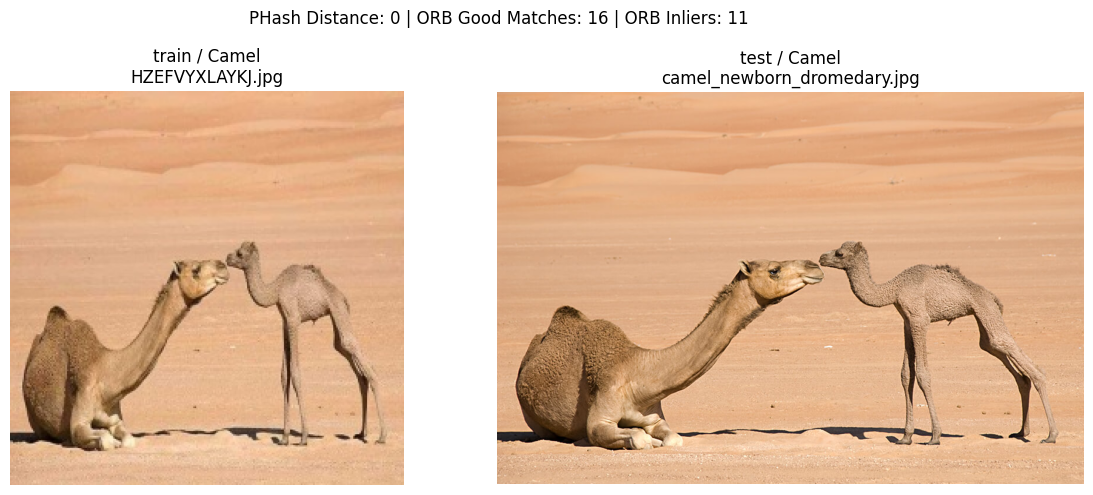

ORB inliers: 16
Good matches: 21
Class: Horse


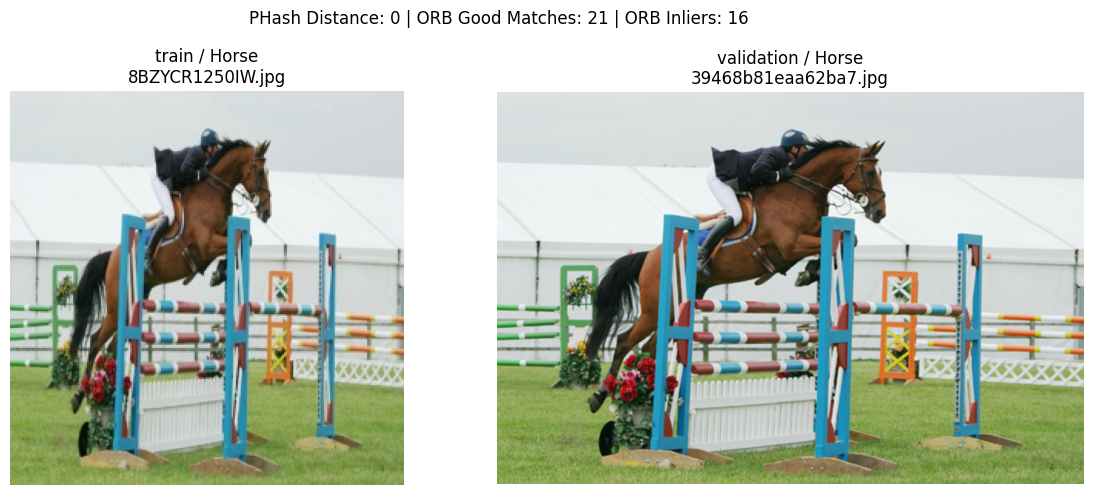

ORB inliers: 20
Good matches: 27
Class: Camel


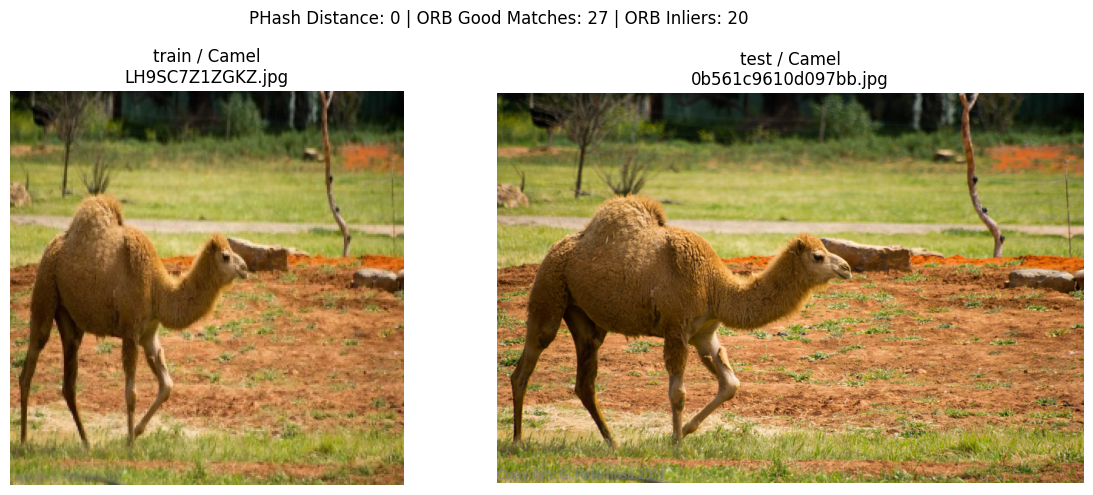

ORB inliers: 26
Good matches: 42
Class: Chicken


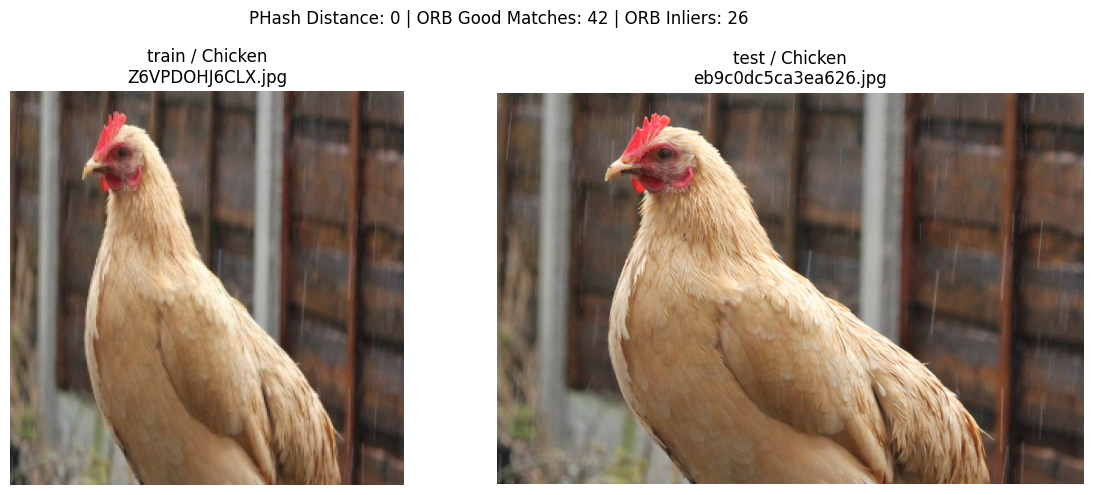

ORB inliers: 47
Good matches: 51
Class: Donkey


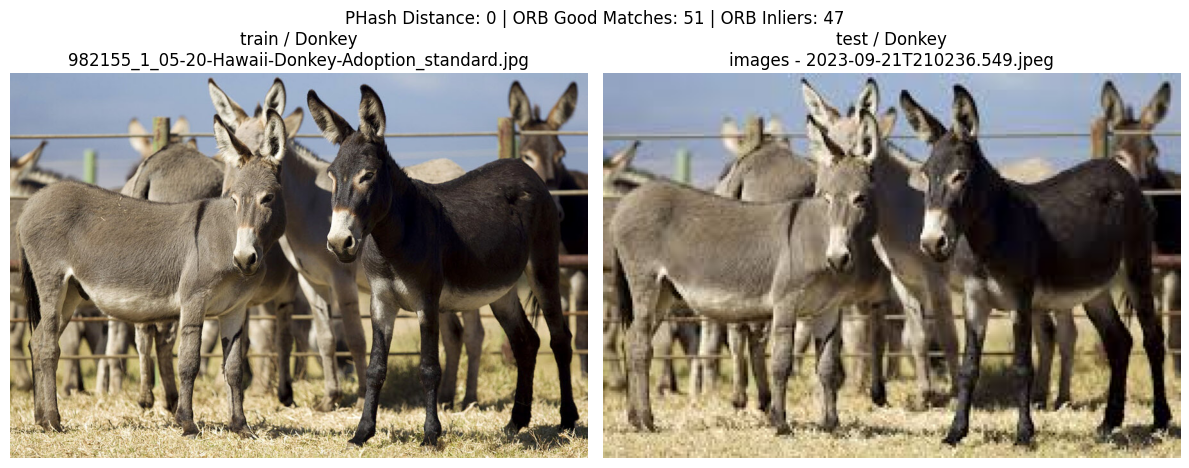

In [28]:
# Select representative pairs from different ORB inlier levels
sample_indices = [
    borderline_pairs.index[0],    # Low end
    borderline_pairs.index[len(borderline_pairs) // 4],
    borderline_pairs.index[len(borderline_pairs) // 2],
    borderline_pairs.index[(3 * len(borderline_pairs)) // 4],
    borderline_pairs.index[-1]     # High end
]

# Display each selected image pair
for pair_index in sample_indices:

    row = orb_df.loc[pair_index]

    print("=" * 70)
    print(f"ORB inliers: {row['inliners']}")
    print(f"Good matches: {row['good_matches']}")
    print(f"Class: {row['class1']}")
    print("=" * 70)

    show_pair(row)

In [29]:
# Count pairs that meet the minimum ORB inlier threshold
confirmed_candidates = orb_df[
    orb_df["inliners"] >= 11
].copy()

print(f"Confirmed duplicate candidates: {len(confirmed_candidates)}")

print("\nBy split combination:")
print(
    confirmed_candidates[
        ["split1", "split2"]
    ].value_counts()
)

Confirmed duplicate candidates: 281

By split combination:
split1      split2    
train       test          139
            validation     93
validation  test           49
Name: count, dtype: int64


In [35]:
!pip install networkx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 13.2 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
# Build groups of images connected by confirmed duplicate relationships
import networkx as nx

graph = nx.Graph()

for _, row in confirmed_candidates.iterrows():
    image1 = row["image1"]
    image2 = row["image2"]

    # Add the two images as connected nodes
    graph.add_edge(image1, image2)

# Find connected groups of duplicate images
duplicate_groups = list(nx.connected_components(graph))

print(f"Duplicate groups found: {len(duplicate_groups)}")

# Show group sizes
group_sizes = sorted(
    [len(group) for group in duplicate_groups],
    reverse=True
)

print("\nLargest duplicate groups:")
print(group_sizes[:20])

Duplicate groups found: 253

Largest duplicate groups:
[6, 5, 5, 4, 4, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [37]:
# Find and inspect the largest duplicate group
largest_group = max(duplicate_groups, key=len)

print(f"Largest group contains {len(largest_group)} images:\n")

for image_path in largest_group:
    # Find the corresponding dataset information
    matches = confirmed_candidates[
        (confirmed_candidates["image1"] == image_path) |
        (confirmed_candidates["image2"] == image_path)
    ]

    print(image_path)

    # Display split/class information from the matching pairs
    for _, row in matches.iterrows():
        if row["image1"] == image_path:
            print(f"  → {row['split1']} / {row['class1']}")
        else:
            print(f"  → {row['split2']} / {row['class2']}")

    print()

Largest group contains 6 images:

..\data\train\Donkey\107916074.jpg
  → train / Donkey

..\data\train\Donkey\1000_F_107916074_mn94Ufm8ueZxXNV6GKW0VACL1PsvSOc5.jpg
  → train / Donkey

..\data\train\Donkey\images - 2023-09-21T210236.400.jpeg
  → train / Donkey

..\data\train\Donkey\360_F_107916074_mn94Ufm8ueZxXNV6GKW0VACL1PsvSOc5.jpg
  → train / Donkey

..\data\test\Donkey\500_F_107916074_mn94Ufm8ueZxXNV6GKW0VACL1PsvSOc5.jpg
  → test / Donkey
  → test / Donkey
  → test / Donkey
  → test / Donkey
  → test / Donkey

..\data\train\Donkey\240_F_107916074_mn94Ufm8ueZxXNV6GKW0VACL1PsvSOc5.jpg
  → train / Donkey



In [38]:
# Summarize which dataset splits appear in each duplicate group
from collections import Counter

group_summary = []

for group_number, group in enumerate(duplicate_groups, start=1):

    splits = []

    for image_path in group:
        # Determine the split from the dataset path
        parts = Path(image_path).parts

        if "train" in parts:
            split = "train"
        elif "validation" in parts:
            split = "validation"
        elif "test" in parts:
            split = "test"
        else:
            split = "unknown"

        splits.append(split)

    counts = Counter(splits)

    group_summary.append({
        "group": group_number,
        "size": len(group),
        "train": counts.get("train", 0),
        "validation": counts.get("validation", 0),
        "test": counts.get("test", 0),
    })

group_summary_df = pd.DataFrame(group_summary)

print("Duplicate groups by split composition:")
print(
    group_summary_df[
        ["train", "validation", "test"]
    ].value_counts().sort_index()
)

Duplicate groups by split composition:
train  validation  test
0      1           1        46
1      0           1       123
                   2         1
       1           0        73
       2           0         1
2      0           1         1
       1           0         3
                   1         1
       2           1         1
3      0           1         1
       2           0         1
5      0           1         1
Name: count, dtype: int64


In [39]:
# Create a cleanup recommendation for each duplicate group.
# Nothing is deleted by this code.

def get_split(image_path):
    """Identify which dataset split an image belongs to."""
    parts = Path(image_path).parts

    if "test" in parts:
        return "test"
    elif "validation" in parts:
        return "validation"
    elif "train" in parts:
        return "train"
    else:
        return "unknown"


# Higher priority means we prefer to keep that split.
split_priority = {
    "test": 3,
    "validation": 2,
    "train": 1
}


cleanup_recommendations = []

for group_number, group in enumerate(duplicate_groups, start=1):

    group_images = list(group)

    # Determine the split of every image in this group.
    image_info = []

    for image_path in group_images:
        split = get_split(image_path)

        image_info.append({
            "path": image_path,
            "split": split
        })

    # Find the highest-priority split present in this group.
    highest_priority = max(
        split_priority[item["split"]]
        for item in image_info
    )

    keep_split = next(
        split
        for split, priority in split_priority.items()
        if priority == highest_priority
    )

    # Keep all images belonging to the highest-priority split.
    # We do not remove multiple images from the same split yet.
    keep_images = [
        item["path"]
        for item in image_info
        if item["split"] == keep_split
    ]

    remove_images = [
        item["path"]
        for item in image_info
        if item["split"] != keep_split
    ]

    cleanup_recommendations.append({
        "group": group_number,
        "group_size": len(group_images),
        "keep_split": keep_split,
        "keep_count": len(keep_images),
        "remove_count": len(remove_images),
        "keep_images": " | ".join(map(str, keep_images)),
        "remove_images": " | ".join(map(str, remove_images))
    })


cleanup_df = pd.DataFrame(cleanup_recommendations)

print(f"Total duplicate groups: {len(cleanup_df)}")
print(f"Groups with removal recommendations: {(cleanup_df['remove_count'] > 0).sum()}")

print("\nRecommended removals by split:")
print(
    cleanup_df[
        ["keep_split", "remove_count"]
    ]
    .groupby("keep_split")
    .sum()
)

cleanup_df.head()

Total duplicate groups: 253
Groups with removal recommendations: 253

Recommended removals by split:
            remove_count
keep_split              
test                 187
validation            83


,group,group_size,keep_split,keep_count,remove_count,keep_images,remove_images
0,1,2,test,1,1,..\data\test\Camel\5M0K2I2A2BSZ.jpg,..\data\train\Camel\Free Shallow Focus Photogr...
1,2,2,test,1,1,..\data\test\Camel\1c68ec73964a0332.jpg,..\data\train\Camel\G4PZDEMX453U.jpg
2,3,2,test,1,1,..\data\test\Camel\4bc1027f1ccb353d.jpg,..\data\train\Camel\GUDRW05GNVCD.jpg
3,4,2,test,1,1,..\data\test\Camel\415AZP8HOFL9.jpg,..\data\train\Camel\happy-camel.jpg
4,5,2,test,1,1,..\data\test\Camel\camel_newborn_dromedary.jpg,..\data\train\Camel\HZEFVYXLAYKJ.jpg


In [40]:
# Find groups where multiple images exist in the highest-priority split.
# These need special handling before we create the final deletion list.

problem_groups = cleanup_df[
    cleanup_df["keep_count"] > 1
].copy()

print(f"Groups with multiple images in the keep split: {len(problem_groups)}")

if len(problem_groups) > 0:
    print("\nThese groups need special handling:")
    print(
        problem_groups[
            ["group", "group_size", "keep_split", "keep_count", "remove_count"]
        ].to_string(index=False)
    )
else:
    print("\nNo problematic groups found.")

Groups with multiple images in the keep split: 3

These groups need special handling:
 group  group_size keep_split  keep_count  remove_count
    74           5 validation           2             3
    86           3       test           2             1
    90           3 validation           2             1


In [41]:
# Display the images and split/class information for the three
# groups that contain multiple images in the keep-priority split.

groups_to_inspect = [74, 86, 90]

for group_number in groups_to_inspect:

    group = duplicate_groups[group_number - 1]

    print("=" * 70)
    print(f"GROUP {group_number} — {len(group)} images")
    print("=" * 70)

    for image_path in group:

        split = get_split(image_path)

        # Find the class from the dataset path
        parts = Path(image_path).parts
        class_name = parts[-2]

        print(f"{split:12} | {class_name:10} | {image_path}")

    print()

GROUP 74 — 5 images
validation   | Donkey     | ..\data\validation\Donkey\1000_F_117351782_ugRMzKUg8pz8ucKVqIPI1JzQSCItC0Hx.jpg
validation   | Donkey     | ..\data\validation\Donkey\240_F_117351782_ugRMzKUg8pz8ucKVqIPI1JzQSCItC0Hx.jpg
train        | Donkey     | ..\data\train\Donkey\360_F_117351782_ugRMzKUg8pz8ucKVqIPI1JzQSCItC0Hx.jpg
train        | Donkey     | ..\data\train\Donkey\funny-donkey-road-transfagarasan-romanian-mountains-75232844 (5).jpg
train        | Donkey     | ..\data\train\Donkey\500_F_117351782_ugRMzKUg8pz8ucKVqIPI1JzQSCItC0Hx.jpg

GROUP 86 — 3 images
train        | Donkey     | ..\data\train\Donkey\donkey-funny-animals-donkey-funny-animals-happy-humorous-donkey-laughing-something-very-very-funny-101898764 (1).jpg
test         | Donkey     | ..\data\test\Donkey\360_F_176786131_KnCinzfMZUaMLeQMKcMoYrBw3UGluQ15.jpg
test         | Donkey     | ..\data\test\Donkey\176786131.jpg

GROUP 90 — 3 images
train        | Donkey     | ..\data\train\Donkey\download (51).jpeg
vali

In [42]:
# Compare duplicate files that exist within the same dataset split.
# We will use this information to choose which copy to keep.

for group_number in [74, 86, 90]:

    group = duplicate_groups[group_number - 1]

    print("=" * 70)
    print(f"GROUP {group_number}")
    print("=" * 70)

    for image_path in group:

        path = Path(image_path)

        try:
            with Image.open(path) as img:
                width, height = img.size

            file_size_kb = path.stat().st_size / 1024

            print(
                f"{get_split(path):12} | "
                f"{path.name[:45]:45} | "
                f"{width}x{height:4} | "
                f"{file_size_kb:8.1f} KB"
            )

        except Exception as error:
            print(f"Could not inspect {path}: {error}")

    print()

GROUP 74
validation   | 1000_F_117351782_ugRMzKUg8pz8ucKVqIPI1JzQSCIt | 1000x 668 |    246.8 KB
validation   | 240_F_117351782_ugRMzKUg8pz8ucKVqIPI1JzQSCItC | 360x 240 |     32.8 KB
train        | 360_F_117351782_ugRMzKUg8pz8ucKVqIPI1JzQSCItC | 539x 360 |     51.1 KB
train        | funny-donkey-road-transfagarasan-romanian-mou | 400x 267 |     22.3 KB
train        | 500_F_117351782_ugRMzKUg8pz8ucKVqIPI1JzQSCItC | 500x 334 |     80.6 KB

GROUP 86
train        | donkey-funny-animals-donkey-funny-animals-hap | 800x 533 |     63.5 KB
test         | 360_F_176786131_KnCinzfMZUaMLeQMKcMoYrBw3UGlu | 541x 360 |     63.1 KB
test         | 176786131.jpg                                 | 361x 240 |     42.4 KB

GROUP 90
train        | download (51).jpeg                            | 479x 360 |     16.5 KB
validation   | 360_F_372909943_Ix9RxvSnevxsixNCaQVPufe89nemR | 479x 360 |     18.4 KB
validation   | 372909943.jpg                                 | 319x 240 |     12.8 KB

